In [1]:
import datetime as dt
import os
import sys

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import healpy as hp
import intake
import matplotlib.pyplot as plt
import metpy.constants as mpconst
import numpy as np
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import (
    get_nn_lon_lat_index,
    haversine,
    hp_mods,
    hp_to_latlon,
    mass_weighted_column_integral,
)

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [5]:
zoom=3
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
# sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=zoom, time='PT3H').to_dask().pipe(hp_mods)
pr = sim_cat(zoom=zoom, time='PT1H').to_dask().pipe(hp_mods).pr
# ds

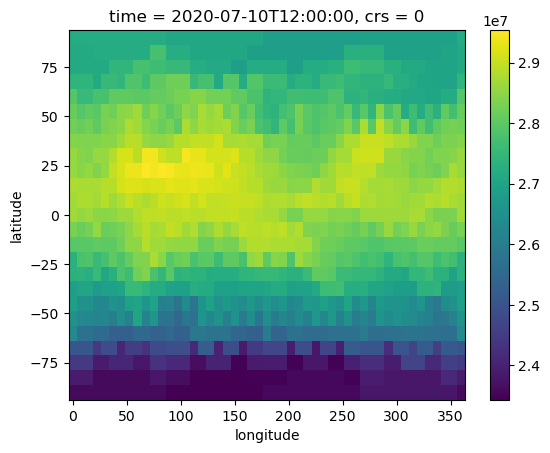

In [6]:

g = mpconst.g.magnitude
cp = mpconst.dry_air_spec_heat_press.magnitude
Lv = mpconst.water_heat_vaporization.magnitude

h = cp * ds.ta + ds.zg + Lv * ds.hus
H = mass_weighted_column_integral(h)

hp_to_latlon(H.sel(time="2020-07-10 12:00"),zoom=zoom).plot()

In [38]:
dwtps = xr.open_dataset(f"../onset_identification/onset_dates/{sim}_zoom_{zoom}_dwtps.nc")
this_lon=10
this_lat=15
this_loc = dwtps.sel(period=0,longitude=this_lon,latitude=this_lat,method="nearest")
first_date = dt.datetime(2020,1,1) + dt.timedelta(days=int(this_loc.first_day_of_period))
last_date = dt.datetime(2020,1,1) + dt.timedelta(days=int(this_loc.last_day_of_period))

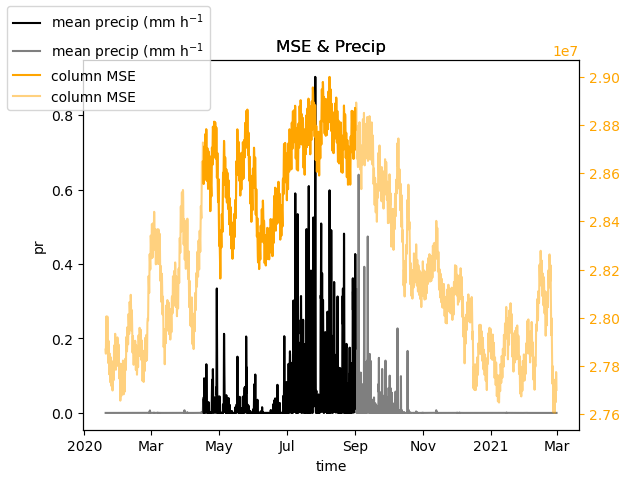

In [39]:
fig, ax1 = plt.subplots()
(
    hp_to_latlon(pr, zoom=zoom)
    .sel(longitude=this_lon, latitude=this_lat, method="nearest")
    .sel(time=slice(first_date, last_date))
    * 3600
).plot(ax=ax1, label="mean precip (mm h$^{-1}$", color="k")

(
    hp_to_latlon(pr, zoom=zoom).sel(
        longitude=this_lon, latitude=this_lat, method="nearest"
    )
    * 3600
).plot(ax=ax1, label="mean precip (mm h$^{-1}$", color="k", alpha=0.5)
ax2 = ax1.twinx()
hp_to_latlon(H, zoom=zoom).sel(
    longitude=this_lon, latitude=this_lat, method="nearest"
).sel(time=slice(first_date, last_date)).plot(
    ax=ax2, label="column MSE", color="orange"
)

hp_to_latlon(H, zoom=zoom).sel(
    longitude=this_lon, latitude=this_lat, method="nearest"
).plot(
    ax=ax2, label="column MSE", color="orange", alpha=0.5
)
ax2.tick_params(axis="y", color="orange", labelcolor="orange")
ax1.set_title("MSE & Precip")
ax2.set_title("MSE & Precip")
fig.legend(loc="upper left")

In [ ]:
,